# Welcome to the Sandbox.
## A place to write and test random stuff

Double click into cells to edit them, this will transform markdown cells from their nicely formatted versions to the actual markdown script the first thing that we have here is a series of basic python scripts to make sure everything is running as expected.

#### The code below is just simple processing on a given list of integers. It makes use of python's ability to simplify 'and' expressions for integer ranges. Very nice.

In [ ]:
#Gatekeeper Code Exercise
population_ages = [10,4,18,12,16,20,26,100,24]
for age in population_ages:
    if age <= 6:
        print('You are ' + str(age) + ' years old and cannot enter')
    elif 6 < age <= 12:
        print('You are ' + str(age) + ' years old and can enter child friendly areas')
    elif 12 < age <= 16:
        print('You are ' + str(age) + ' years old and can enter with an adult')
    elif age >= 17:
        print('You are ' + str(age) + ' years old and can enter freely')
    else:
        print('somehow palpatine returned?')

## Challenge:
Write a login program that asks a user for username and password, which are predefined. Full brief [**here**](https://vle.aston.ac.uk/ultra/courses/_62426_1/outline/edit/document/_4285221_1?courseId=_62426_1&view=content&state=view)


In [ ]:
#set up a login bools for while loop
good_login:bool = False
attempts:int = 0
while not good_login and attempts < 3:
    #Request username
    username:str = input("Enter your username: ")
    #Request password
    password:str = input("Enter your password: ")
    if username == 'admin' and password == 'password123':
        print('You are logged in')
        good_login = True
    elif username.lower() == 'quit' and password.lower() == '':
        break
    else:
        attempts += 1
        if attempts < 3:
            print("You are not logged in and have %d attempts left, check your username and password and try again or enter username: QUIT password: *blank* to exit the application" % (3-attempts))
print('Allowed attempts exceeded or an error occurred. Please try again later')

# Course Work Data Playground

## Imports

In [47]:
import pandas as pd
import pandasql as ps
import json
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler

## Playground

In [48]:
with open('ingest_schema.json') as f:
    schema = json.load(f)

#Read in the whole CSV.
#df_all_str = pd.read_csv("CW_data.csv",dtype = str, encoding='ANSI')
#df_all.shape
#df_all_str[df_all_str.apply(lambda col: col.str.contains('FALSE')).any(axis=1)]

df_all = pd.read_csv(
    filepath_or_buffer ="CW_data.csv",
    encoding='ANSI',
    dtype = schema,
    true_values = ["positive"],
    false_values = ["negative"],
    on_bad_lines = "warn"
    )
print(df_all.dtypes)


Patient ID                                  object
Patient age quantile                         Int64
feat_Hematocrit                            Float64
feat_Hemoglobin                            Float64
feat_Platelets                             Float64
                                            ...   
feat_pO2 (arterial blood gas analysis)     Float64
feat_Arteiral Fio2                         Float64
feat_Phosphor                              Float64
feat_ctO2 (arterial blood gas analysis)    Float64
SARS-Cov-2 exam result                        bool
Length: 108, dtype: object


## Handling The Non-Numerics

In [ ]:
#deal with non-numeric data points

In [51]:
df_all.head(10)

shape is (1496, 100)


,Patient age quantile,feat_Hematocrit,feat_Hemoglobin,feat_Platelets,feat_Mean platelet volume,feat_Red blood Cells,feat_Lymphocytes,feat_Mean corpuscular hemoglobin concentration (MCHC),feat_Leukocytes,feat_Basophils,...,feat_pCO2 (arterial blood gas analysis),feat_Base excess (arterial blood gas analysis),feat_pH (arterial blood gas analysis),feat_Total CO2 (arterial blood gas analysis),feat_HCO3 (arterial blood gas analysis),feat_pO2 (arterial blood gas analysis),feat_Arteiral Fio2,feat_Phosphor,feat_ctO2 (arterial blood gas analysis),SARS-Cov-2 exam result
0,9,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False
6,4,0.80873,0.60422,-0.002379,-0.886869,0.295938,-1.421559,-0.552476,2.443296,-0.529226,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False
7,13,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False
9,6,1.335167,1.544059,-0.002379,-0.101517,1.230347,-0.099557,1.040773,-0.768046,1.303529,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False
10,19,0.556955,0.478908,-0.969638,1.132609,0.119635,-0.756294,-0.154166,-0.656734,-0.529226,...,-0.728448,-0.091579,0.656366,-0.872898,-0.848024,-0.956242,-0.011744,<NA>,0.079928,True
14,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False
16,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False
17,11,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False
18,19,0.488289,0.729532,0.148363,0.010677,0.542763,-1.319211,1.040773,0.439686,-0.834685,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False
21,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False


Seems to be some useless columns with just values of NA. I could find a way to drop columns with all NA, but it might be worth dropping columns with all values that are identical, regardless of if they are NaN or not. I think this is the correct choice as a column with all the same value will likely not provide any good information for the model to interpret and find trends. It would also lead to issues when looking at the test data set as if a col in the development data is full of a single value but in the test data it has multiple values, the algorithm will not have sufficient knowledge to assess the weight of those other differing values. Therefore, exclude all cols that have only got one unique value.

In [54]:
missing_per_column = df_all.isnull().sum(axis=0)
plt.plot(missing_per_column)
df_single_values =  df_all.loc[:, df_all.nunique(dropna = False) == 1]
print(df_single_values.columns)

The average number of missing values is 1173.78. There are 63 columns with missing values over the average. They are: feat_Serum Glucose                         1348
feat_Urea                                  1207
feat_Creatinine                            1184
feat_Potassium                             1222
feat_Sodium                                1222
                                           ... 
feat_HCO3 (arterial blood gas analysis)    1479
feat_pO2 (arterial blood gas analysis)     1479
feat_Arteiral Fio2                         1484
feat_Phosphor                              1479
feat_ctO2 (arterial blood gas analysis)    1479
Length: 63, dtype: int64


In [55]:
df_single_values.head()

feat_Serum Glucose                         1348
feat_Urea                                  1207
feat_Potassium                             1222
feat_Sodium                                1222
feat_Alanine transaminase                  1334
                                           ... 
feat_HCO3 (arterial blood gas analysis)    1479
feat_pO2 (arterial blood gas analysis)     1479
feat_Arteiral Fio2                         1484
feat_Phosphor                              1479
feat_ctO2 (arterial blood gas analysis)    1479
Length: 62, dtype: int64

In [56]:
#df_single_values.columns
df_filtered = df_all.drop(labels = df_single_values.columns, axis = 1)
pd.set_option('display.max_rows', None)
print(df_filtered.dtypes)

(1496, 38)

In [57]:
missing_per_column = df_filtered.isnull().sum(axis=0)
#print(missing_per_column)
plt.plot(missing_per_column)

,Patient age quantile,feat_Hematocrit,feat_Hemoglobin,feat_Platelets,feat_Mean platelet volume,feat_Red blood Cells,feat_Lymphocytes,feat_Mean corpuscular hemoglobin concentration (MCHC),feat_Leukocytes,feat_Basophils,...,feat_Inf A H1N1 2009,feat_Bordetella pertussis,feat_Metapneumovirus,feat_Parainfluenza 2,feat_Neutrophils,feat_Proteina C reativa mg/dL,feat_Creatinine,"feat_Influenza B, rapid test","feat_Influenza A, rapid test",SARS-Cov-2 exam result
0,9,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,...,detected,not_detected,not_detected,not_detected,<NA>,<NA>,<NA>,NaN,NaN,False
6,4,0.80873,0.60422,-0.002379,-0.886869,0.295938,-1.421559,-0.552476,2.443296,-0.529226,...,NaN,NaN,NaN,NaN,1.462405,0.07465,<NA>,negative,negative,False
7,13,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,...,not_detected,not_detected,not_detected,not_detected,<NA>,<NA>,<NA>,NaN,NaN,False
9,6,1.335167,1.544059,-0.002379,-0.101517,1.230347,-0.099557,1.040773,-0.768046,1.303529,...,NaN,NaN,NaN,NaN,0.10206,-0.529401,<NA>,NaN,NaN,False
10,19,0.556955,0.478908,-0.969638,1.132609,0.119635,-0.756294,-0.154166,-0.656734,-0.529226,...,not_detected,not_detected,not_detected,not_detected,0.618335,0.801897,0.125653,NaN,NaN,True
14,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,...,not_detected,not_detected,not_detected,not_detected,<NA>,<NA>,<NA>,negative,negative,False
16,1,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,...,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,negative,negative,False
17,11,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,...,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,negative,negative,False
18,19,0.488289,0.729532,0.148363,0.010677,0.542763,-1.319211,1.040773,0.439686,-0.834685,...,NaN,NaN,NaN,NaN,2.126187,<NA>,<NA>,NaN,NaN,False
21,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,...,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,negative,negative,False


In [58]:
missing_per_row = df_filtered.isnull().sum(axis=1)
plt.plot(abs(missing_per_row))
print(missing_per_row)

Index(['Patient age quantile', 'feat_Hematocrit', 'feat_Hemoglobin',
       'feat_Platelets', 'feat_Mean platelet volume', 'feat_Red blood Cells',
       'feat_Lymphocytes',
       'feat_Mean corpuscular hemoglobin concentration (MCHC)',
       'feat_Leukocytes', 'feat_Basophils',
       'feat_Mean corpuscular hemoglobin (MCH)', 'feat_Eosinophils',
       'feat_Mean corpuscular volume (MCV)', 'feat_Monocytes',
       'feat_Red blood cell distribution width (RDW)', 'feat_Neutrophils',
       'feat_Proteina C reativa mg/dL', 'feat_Creatinine'],
      dtype='object')


In [37]:
df_numerics = df_filtered.select_dtypes(include = 'number')
print(df_numerics.columns)

""
0
6
7
9
10
14
16
17
18
21


classifiers shape is (1496,)
scaled predictor shape is: (1496, 18)


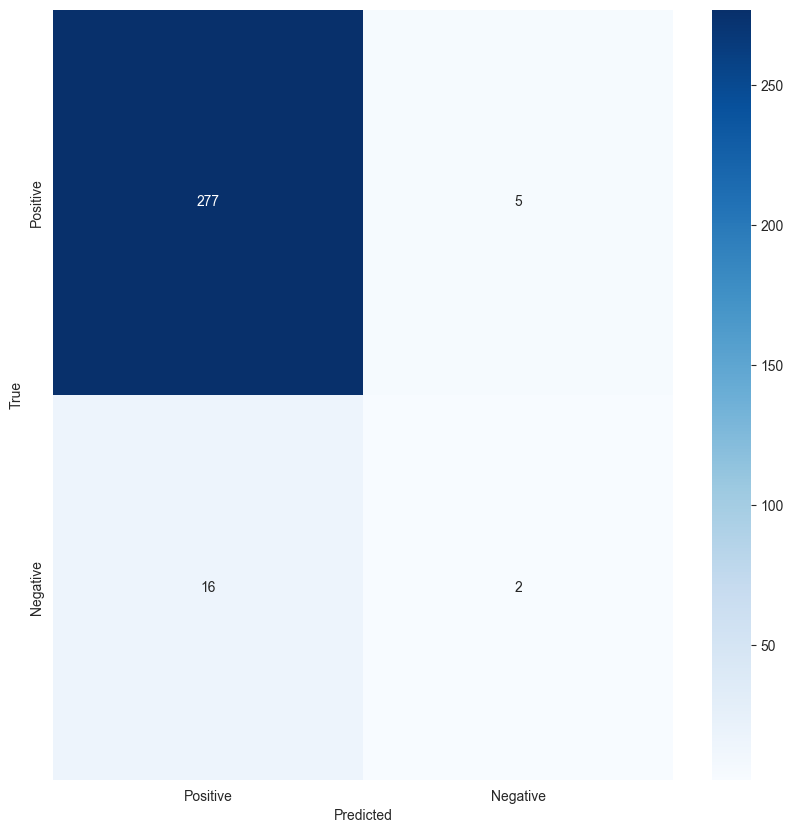

In [60]:
# get means and std deviations
df_stats = pd.concat([df_numerics.mean(), df_numerics.std()], axis = 1)
df_stats.head()

## Attempting PCA
### this needs non numerical columns to be dealt with first and NANs to be handled

classifiers shape is (3999,)
scaled predictor shape is: (3999, 64)


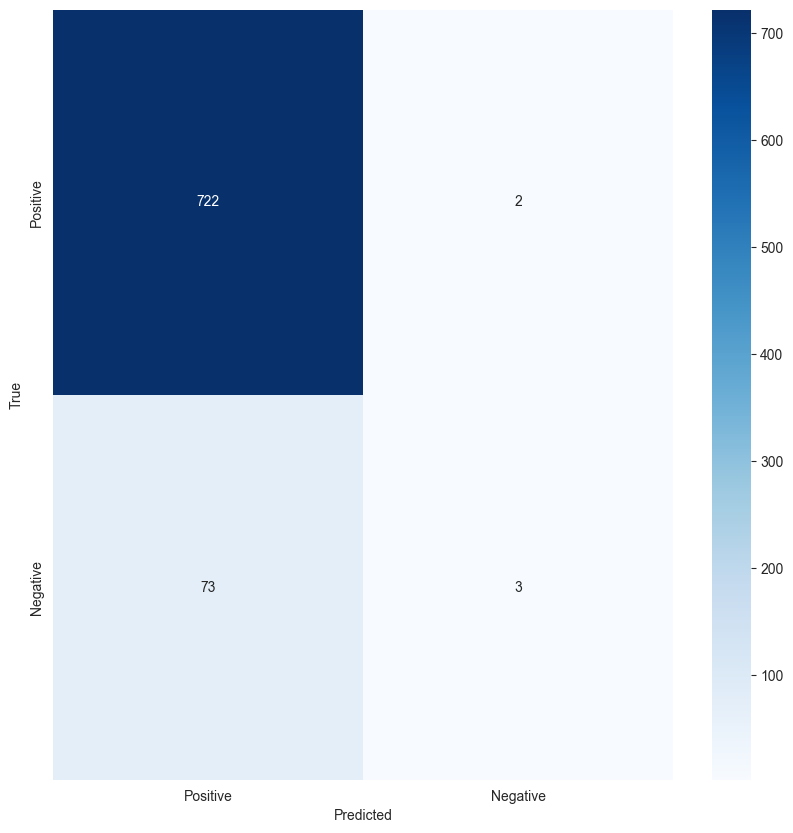

In [23]:
#Grab classifiers
df_classifiers = df_filtered['SARS-Cov-2 exam result']
print(f'classifiers shape is {df_classifiers.shape}')
#deal with NANs in the numerical - this will need to be done properly with outlier handling, but for now, fuck it. MEAN TIME BABY
df_no_nan_numerics = df_numerics.fillna(df_numerics.mean())

#Scale this shit down
scaler = StandardScaler()
df_scaled_predictors = scaler.fit_transform(df_no_nan_numerics)
print(f'scaled predictor shape is: {df_scaled_predictors.shape}')

#create a pca and fit that bitch up
pca = PCA(n_components = 10)
predictor_pca = pca.fit_transform(df_scaled_predictors)

#split em
predictor_train, predictor_test, classifier_train, classifier_test = train_test_split(predictor_pca, df_classifiers, test_size = 0.2)

#predict em
model = LogisticRegression()
model.fit(predictor_train, classifier_train)
classifier_pred = model.predict(predictor_test)

#visualise em
cm = confusion_matrix(classifier_test, classifier_pred)
plt.figure(figsize = (10,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Positive', 'Negative'], yticklabels=['Positive', 'Negative'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()